In [26]:
import pandas as pd
from glob import glob

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, learning_curve, train_test_split
from sklearn.linear_model import LogisticRegression

import numpy as np
from imblearn.over_sampling import SMOTE

def get_whole_df() -> pd.DataFrame:
    files = glob("combined_part_*.csv")
    df_list = []
    for file in files:
        df_list.append(pd.read_csv(file))

    return pd.concat(df_list, ignore_index=True)

df = get_whole_df()
# print(df.info())
# print("Null: "+str(df.isnull().sum()))
# print(df.columns.values)
# print(df[[" Flow Packets/s", "Flow Bytes/s"]].describe())



In [27]:
# strip whitespace from the headers first
df.columns = df.columns.str.strip()
# print(df.columns.values)

# print("Rows:", len(df))
# print("Duplicate rows:", df.duplicated().sum())
data = df.drop_duplicates()
# print(data["Label"].value_counts())

# Replace infinities with a finite number (e.g. 0 or the column mean)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# # drop minor class:
df = df[df["Label"] != "Heartbleed"]

In [28]:
X = df.drop("Label", axis=1)
y = df["Label"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="weighted")
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })
    
    print(f"\n{name}")
    print(classification_report(y_test, pred))
results_df = pd.DataFrame(results)
print(results_df)

C:\Users\silas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
                  precision    recall  f1-score   support

          BENIGN       0.94      0.83      0.88     87936
   DoS GoldenEye       0.66      0.96      0.78      2059
        DoS Hulk       0.96      0.90      0.93     46025
DoS Slowhttptest       0.11      0.94      0.20      1100
   DoS slowloris       0.18      0.86      0.30      1159

        accuracy                           0.86    138279
       macro avg       0.57      0.90      0.62    138279
    weighted avg       0.93      0.86      0.89    138279


Random Forest
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     87936
   DoS GoldenEye       0.99      1.00      0.99      2059
        DoS Hulk       1.00      1.00      1.00     46025
DoS Slowhttptest       0.99      0.99      0.99      1100
   DoS slowloris       0.99      0.99      0.99      1159

        accuracy                           1.00    138279
       macro avg       0.99    

Label
DoS Hulk            351747
BENIGN              351747
DoS GoldenEye       351747
DoS Slowhttptest    351747
DoS slowloris       351747
Name: count, dtype: int64


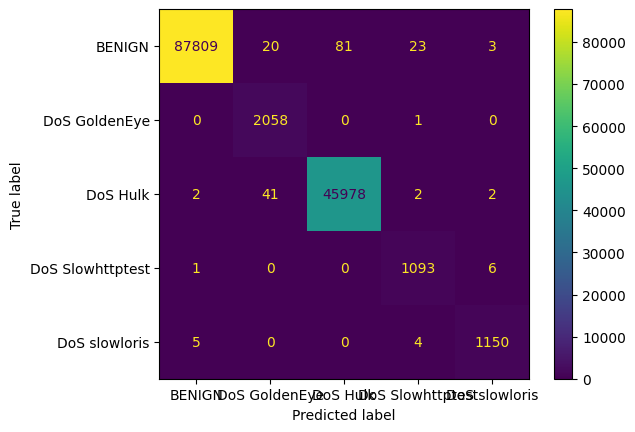

In [30]:
print(pd.Series(y_train_res).value_counts())
ConfusionMatrixDisplay.from_predictions(y_test, pred)

In [31]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

Min Packet Length              0.103575
Destination Port               0.086904
Total Length of Bwd Packets    0.084516
Active Min                     0.078064
Bwd IAT Min                    0.077649
Fwd IAT Std                    0.073688
Flow IAT Min                   0.047928
Subflow Bwd Bytes              0.037871
Average Packet Size            0.035629
Flow IAT Std                   0.034049
dtype: float64


In [32]:
train_pred = model.predict(X_train_res)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train_res, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.9984670800319548
Test accuracy: 0.9986187345873199


In [ ]:
scores = cross_val_score(model, X, y, cv=5)

print(scores)
print("Mean accuracy:", scores.mean())

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5
)

print("Train score:", np.mean(train_scores))
print("Test score:", np.mean(test_scores))